# 10c — GRDI Poverty Index as a Spatial Proxy for Vulnerability

Adapts notebook 10b (GDP) to use the **CIESIN Global Gridded Relative Deprivation Index (GRDI), v1**
in place of the Kummu et al. GDP raster.

**Why GRDI instead of GDP?**  
GDP measures economic output — it is a production metric, not a direct deprivation measure.
GRDI is a multidimensional index (child dependency ratio, infant mortality, HDI, built-up area,
nighttime lights) purpose-built to characterise relative poverty and deprivation at ~1 km resolution.
Higher GRDI → more deprived → **higher** vulnerability (the direction is inverted vs GDP).

**What this notebook does:**
1. Extracts a city-level GeoTIFF from the global GRDI raster (cached).
2. Computes mean GRDI per neighbourhood via zonal statistics.
3. Compares GRDI spatial patterns with heat exposure and population.
4. Computes Spearman rank correlations between GRDI and heat/population metrics.
5. Produces GRDI-weighted person-day indices (vulnerability ∝ GRDI).
6. Compares GRDI ranks with census income ranks for Salvador (if income GeoJSON present).

**Important:**  
GRDI is a relative index (0–100); a value of 100 = highest deprivation, 0 = lowest.  
Cross-city absolute values are comparable (unlike GDP which mixes area and output).  
CRS: EPSG:4326 (WGS84), resolution ~0.01° (~1 km at equator).

**Data:** `data/povmap-grdi-v1-grdiv1-geotiff/povmap-grdi-v1.tif`  
Source: CIESIN/NASA SEDAC https://doi.org/10.7927/3xxe-ap97  

**Prerequisites:** `01_data_acquisition`, `02_compute_baselines`, `07_person_days_diagnostic`.

## Setup

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import geopandas as gpd
import xarray as xr
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.windows import from_bounds as window_from_bounds
from scipy.stats import spearmanr
from shapely.geometry import mapping

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES,
    load_city, load_tx90p_threshold, load_neighbourhood_boundaries,
    compute_absolute_heat_days, compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

# ---- Configuration ----------------------------------------------------------
DATA_DIR      = 'data'
GRDI_TIF      = 'data/povmap-grdi-v1-grdiv1-geotiff/povmap-grdi-v1.tif'
GRDI_CRS      = 'EPSG:4326'   # native CRS of the GRDI raster
BUFFER_DEG    = 0.05          # ~5 km buffer around city bbox when extracting window
DIAG_YEAR     = 2020
ABS_THRESHOLD = 30.0
PERCENTILE    = 90
CITY_KEYS     = ['salvador', 'teresina', 'caceres']

CITY_LABELS = {
    'salvador': 'Salvador',
    'teresina': 'Teresina',
    'caceres':  'Cáceres',
}

CITY_PROJ_CRS = {
    'salvador':  'EPSG:31984',
    'teresina':  'EPSG:31983',
    'caceres':   'EPSG:31981',
}

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th',      'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td',      'props': 'text-align:center; font-size:0.85em;'},
]

def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

def count_doy_exceedances(da, thresh_doy):
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')

print(f'GRDI source: {GRDI_TIF}')
print(f'GRDI CRS: {GRDI_CRS}  (WGS84 — no reprojection needed)')

GRDI source: data/povmap-grdi-v1-grdiv1-geotiff/povmap-grdi-v1.tif
GRDI CRS: EPSG:4326  (WGS84 — no reprojection needed)


## Step 1 — Extract city GRDI windows from the global raster

The GRDI raster is in WGS84 (EPSG:4326), so city bounding boxes can be used directly
without reprojection.  A small buffer is added to ensure full neighbourhood coverage at the
city edge.  Extracted windows are cached in `data/grdi_{city}.tif`.

In [2]:
def extract_city_grdi(city_key, data_dir=DATA_DIR, grdi_tif=GRDI_TIF, buffer_deg=BUFFER_DEG):
    """Extract GRDI window for a city bbox and cache as a GeoTIFF."""
    out_path = Path(data_dir) / f'grdi_{city_key}.tif'
    if out_path.exists():
        sz_kb = out_path.stat().st_size / 1024
        print(f'  {city_key}: cache found — {out_path.name} ({sz_kb:.0f} KB)')
        return out_path

    cfg  = CITIES[city_key]
    bbox = cfg['bbox']

    west  = bbox['west']  - buffer_deg
    east  = bbox['east']  + buffer_deg
    south = bbox['south'] - buffer_deg
    north = bbox['north'] + buffer_deg

    with rasterio.open(grdi_tif) as src:
        win = window_from_bounds(west, south, east, north, src.transform)
        win = win.round_offsets().round_lengths()
        arr           = src.read(1, window=win)
        win_transform = src.window_transform(win)

        profile = src.profile.copy()
        profile.update({
            'height':    int(win.height),
            'width':     int(win.width),
            'transform': win_transform,
            'compress':  'lzw',
            'tiled':     False,
        })

        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(arr, 1)

    sz_kb = out_path.stat().st_size / 1024
    print(f'  {city_key}: extracted {int(win.height)}×{int(win.width)} px '
          f'→ {out_path.name} ({sz_kb:.0f} KB)')
    return out_path


print(f'Extracting city windows from GRDI raster:')
grdi_tif_paths = {}
for city in CITY_KEYS:
    grdi_tif_paths[city] = extract_city_grdi(city)

print('\nGRDI value ranges in extracted windows (0=least deprived, 100=most deprived):')
for city, tif_path in grdi_tif_paths.items():
    with rasterio.open(tif_path) as src:
        arr    = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr[np.isclose(arr, nodata)] = np.nan
        valid  = arr[np.isfinite(arr)]
    print(f'  {city:12s}  n_px={len(valid):5d}  '
          f'min={valid.min():.1f}  median={np.median(valid):.1f}  max={valid.max():.1f}')

Extracting city windows from GRDI raster:
  salvador: extracted 72×84 px → grdi_salvador.tif (3 KB)
  teresina: extracted 84×96 px → grdi_teresina.tif (7 KB)
  caceres: extracted 108×108 px → grdi_caceres.tif (2 KB)

GRDI value ranges in extracted windows (0=least deprived, 100=most deprived):
  salvador      n_px=  523  min=6.6  median=47.0  max=72.7
  teresina      n_px= 1414  min=14.6  median=70.5  max=78.4
  caceres       n_px=   48  min=23.0  median=33.2  max=74.4


## Step 2 — Load neighbourhood boundaries

In [3]:
districts = {}
for city in CITY_KEYS:
    gdf = load_neighbourhood_boundaries(city, DATA_DIR)
    districts[city] = gdf
    print(f'  {city}: {len(gdf)} neighbourhoods, CRS={gdf.crs}')

Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
  salvador: 22 neighbourhoods, CRS=EPSG:4326
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
  teresina: 112 neighbourhoods, CRS=EPSG:4326
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg
  caceres: 43 neighbourhoods, CRS=EPSG:4326


## Step 3 — Zonal statistics: mean GRDI per neighbourhood

Because the GRDI raster is already in WGS84, neighbourhood polygons (also WGS84)
are used directly without reprojection.  `all_touched=True` ensures that small
neighbourhoods smaller than a single pixel still receive a value.

In [4]:
def grdi_zonal_stats(gdf_4326, grdi_tif_path):
    """Mean GRDI per neighbourhood.  Returns DataFrame: name, mean_grdi, n_grdi_px."""
    with rasterio.open(grdi_tif_path) as src:
        nodata = src.nodata

    rows = []
    with rasterio.open(grdi_tif_path) as src:
        for _, row in gdf_4326.iterrows():
            try:
                out_arr, _ = rio_mask(
                    src, [mapping(row.geometry)], crop=True,
                    nodata=nodata, all_touched=True,
                )
                vals = out_arr[0].astype(float)
                if nodata is not None:
                    vals[np.isclose(vals, nodata)] = np.nan
                valid    = vals[np.isfinite(vals)]
                mean_val = float(valid.mean()) if len(valid) > 0 else np.nan
                n_px     = int(len(valid))
            except Exception:
                mean_val, n_px = np.nan, 0
            rows.append({'name': row['name'], 'mean_grdi': mean_val, 'n_grdi_px': n_px})

    return pd.DataFrame(rows)


print('Computing GRDI zonal statistics per neighbourhood:')
grdi_by_nbhd = {}
for city in CITY_KEYS:
    df = grdi_zonal_stats(districts[city], grdi_tif_paths[city])
    n_missing = df['mean_grdi'].isna().sum()
    grdi_by_nbhd[city] = df
    print(f'  {city}: {len(df)} neighbourhoods, '
          f'{n_missing} missing, '
          f'mean GRDI={df["mean_grdi"].mean():.1f}')

print('\nGRDI units: 0–100 index (100 = highest relative deprivation).')
print('Note: all_touched=True used to capture neighbourhoods smaller than one pixel.')

Computing GRDI zonal statistics per neighbourhood:
  salvador: 22 neighbourhoods, 0 missing, mean GRDI=38.7
  teresina: 112 neighbourhoods, 0 missing, mean GRDI=42.7
  caceres: 43 neighbourhoods, 1 missing, mean GRDI=30.4

GRDI units: 0–100 index (100 = highest relative deprivation).
Note: all_touched=True used to capture neighbourhoods smaller than one pixel.


## Step 4 — Load heat and population metrics for all three cities

In [5]:
def build_heat_pop_table(city_key, diag_year=DIAG_YEAR, abs_threshold=ABS_THRESHOLD,
                         percentile=PERCENTILE, data_dir=DATA_DIR):
    da     = load_city(city_key, data_dir)
    da.attrs['units'] = 'degC'
    thresh = load_tx90p_threshold(city_key, data_dir)
    pop    = load_pop_grid(city_key, diag_year)
    nbhd   = districts[city_key]

    abs_hd = compute_absolute_heat_days(da, diag_year, abs_threshold)

    tx_annual = count_doy_exceedances(da, thresh.sel(percentile=percentile))
    tx_hd = (
        tx_annual
        .isel(time=(tx_annual.time.dt.year == diag_year))
        .squeeze('time')
    )

    pop_nbhd    = aggregate_person_days_to_neighbourhoods(pop,    nbhd, col='population')
    abs_hd_nbhd = aggregate_to_neighbourhoods(abs_hd, nbhd, col='abs_hd')
    tx_hd_nbhd  = aggregate_to_neighbourhoods(tx_hd,  nbhd, col='tx90p_hd')
    abs_pd_nbhd = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(abs_hd, pop), nbhd, col='abs_pd')
    tx_pd_nbhd  = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(tx_hd, pop),  nbhd, col='tx90p_pd')

    df = nbhd[['name']].copy()
    df['population'] = pop_nbhd['population'].values
    df['abs_hd']     = abs_hd_nbhd['abs_hd'].values
    df['tx90p_hd']   = tx_hd_nbhd['tx90p_hd'].values
    df['abs_pd']     = abs_pd_nbhd['abs_pd'].values
    df['tx90p_pd']   = tx_pd_nbhd['tx90p_pd'].values
    return df.dropna().reset_index(drop=True)


heat_pop = {}
for city in CITY_KEYS:
    print(f'--- {city} ---')
    heat_pop[city] = build_heat_pop_table(city)
    print(f'    {len(heat_pop[city])} neighbourhoods\n')

--- salvador ---
salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 26.0–73.7 °C
    22 neighbourhoods

--- teresina ---
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
teresina TX90p threshold: shape {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 32.7–60.4 °C
    112 neighbourhoods

--- caceres ---
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
caceres TX90p threshold: shape {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 30.9–43.9 °C
    43 neighbourhoods



## Step 5 — Merge GRDI into city tables

In [6]:
city_df = {}
for city in CITY_KEYS:
    df = heat_pop[city].merge(grdi_by_nbhd[city][['name', 'mean_grdi', 'n_grdi_px']],
                              on='name', how='left')
    n_missing = df['mean_grdi'].isna().sum()
    if n_missing:
        print(f'WARNING {city}: {n_missing} neighbourhood(s) with no GRDI data')
    df = df.dropna(subset=['mean_grdi']).reset_index(drop=True)

    for col in ['population', 'abs_hd', 'tx90p_hd', 'abs_pd', 'tx90p_pd', 'mean_grdi']:
        df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)

    city_df[city] = df
    print(f'{city}: {len(df)} neighbourhoods merged')

# Preview Salvador — sorted by deprivation (highest GRDI first)
display(city_df['salvador'][['name', 'population', 'tx90p_hd', 'tx90p_pd', 'mean_grdi', 'n_grdi_px']]
    .sort_values('mean_grdi', ascending=False)
    .style
    .format({'population': '{:,.0f}', 'tx90p_hd': '{:.1f}',
             'tx90p_pd': '{:,.0f}', 'mean_grdi': '{:.1f}', 'n_grdi_px': '{:.0f}'})
    .background_gradient(subset=['mean_grdi'], cmap='YlOrRd')
    .set_caption(f'Salvador — heat, population, GRDI ({DIAG_YEAR} heat/pop; GRDI v1 2010–2020)')
    .set_table_styles(table_styles))

salvador: 22 neighbourhoods merged
teresina: 112 neighbourhoods merged
WARNING caceres: 1 neighbourhood(s) with no GRDI data
caceres: 42 neighbourhoods merged


,name,population,tx90p_hd,tx90p_pd,mean_grdi,n_grdi_px
8,Maré,"3,361",6.9,"14,843",63.3,3
20,Valéria,"184,514",10.3,"1,814,978",46.0,41
11,Paripe,"178,883",0.9,"1,226,715",43.6,67
14,Periperi,"63,194",10.4,"564,834",42.4,18
6,São Caetano,"395,082",11.2,"4,303,580",42.4,51
5,Santo Antônio,"195,988",7.0,"1,562,627",41.5,18
1,Brotas,"177,034",11.7,"2,078,214",41.1,26
7,São Cristovão,"97,518",11.0,"1,161,960",41.0,41
3,Itapoã,"161,716",11.3,"1,982,070",39.5,61
21,Vitória,"139,139",8.5,"1,167,467",39.0,24


## Step 6 — GRDI spatial pattern: choropleth maps (all three cities)

Higher values (darker red) = more deprived neighbourhoods.

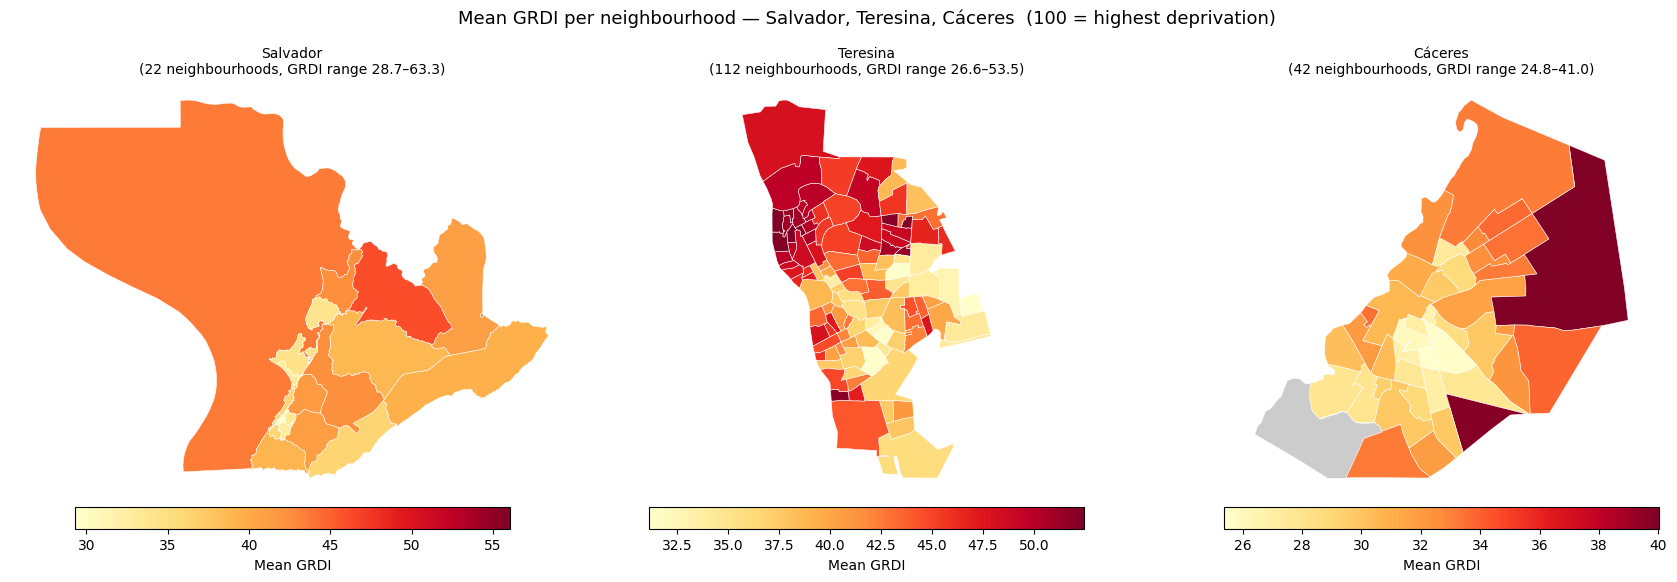

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Mean GRDI per neighbourhood — Salvador, Teresina, Cáceres  '
    '(100 = highest deprivation)',
    fontsize=13,
)

for ax, city in zip(axes, CITY_KEYS):
    df  = city_df[city]
    gdf = districts[city].merge(df[['name', 'mean_grdi']], on='name', how='left')
    vmin = df['mean_grdi'].quantile(0.02)
    vmax = df['mean_grdi'].quantile(0.98)

    gdf.plot(
        column='mean_grdi', ax=ax, cmap='YlOrRd',
        vmin=vmin, vmax=vmax,
        edgecolor='white', linewidth=0.4,
        legend=True,
        legend_kwds={
            'label': 'Mean GRDI', 'orientation': 'horizontal',
            'shrink': 0.7, 'pad': 0.02,
        },
        missing_kwds={'color': '#cccccc', 'label': 'No data'},
    )
    ax.set_title(
        f'{CITY_LABELS[city]}\n'
        f'({len(df)} neighbourhoods, GRDI range {df["mean_grdi"].min():.1f}–{df["mean_grdi"].max():.1f})',
        fontsize=10,
    )
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Step 6b — Side-by-side: GRDI vs TX90p heat days (all three cities)

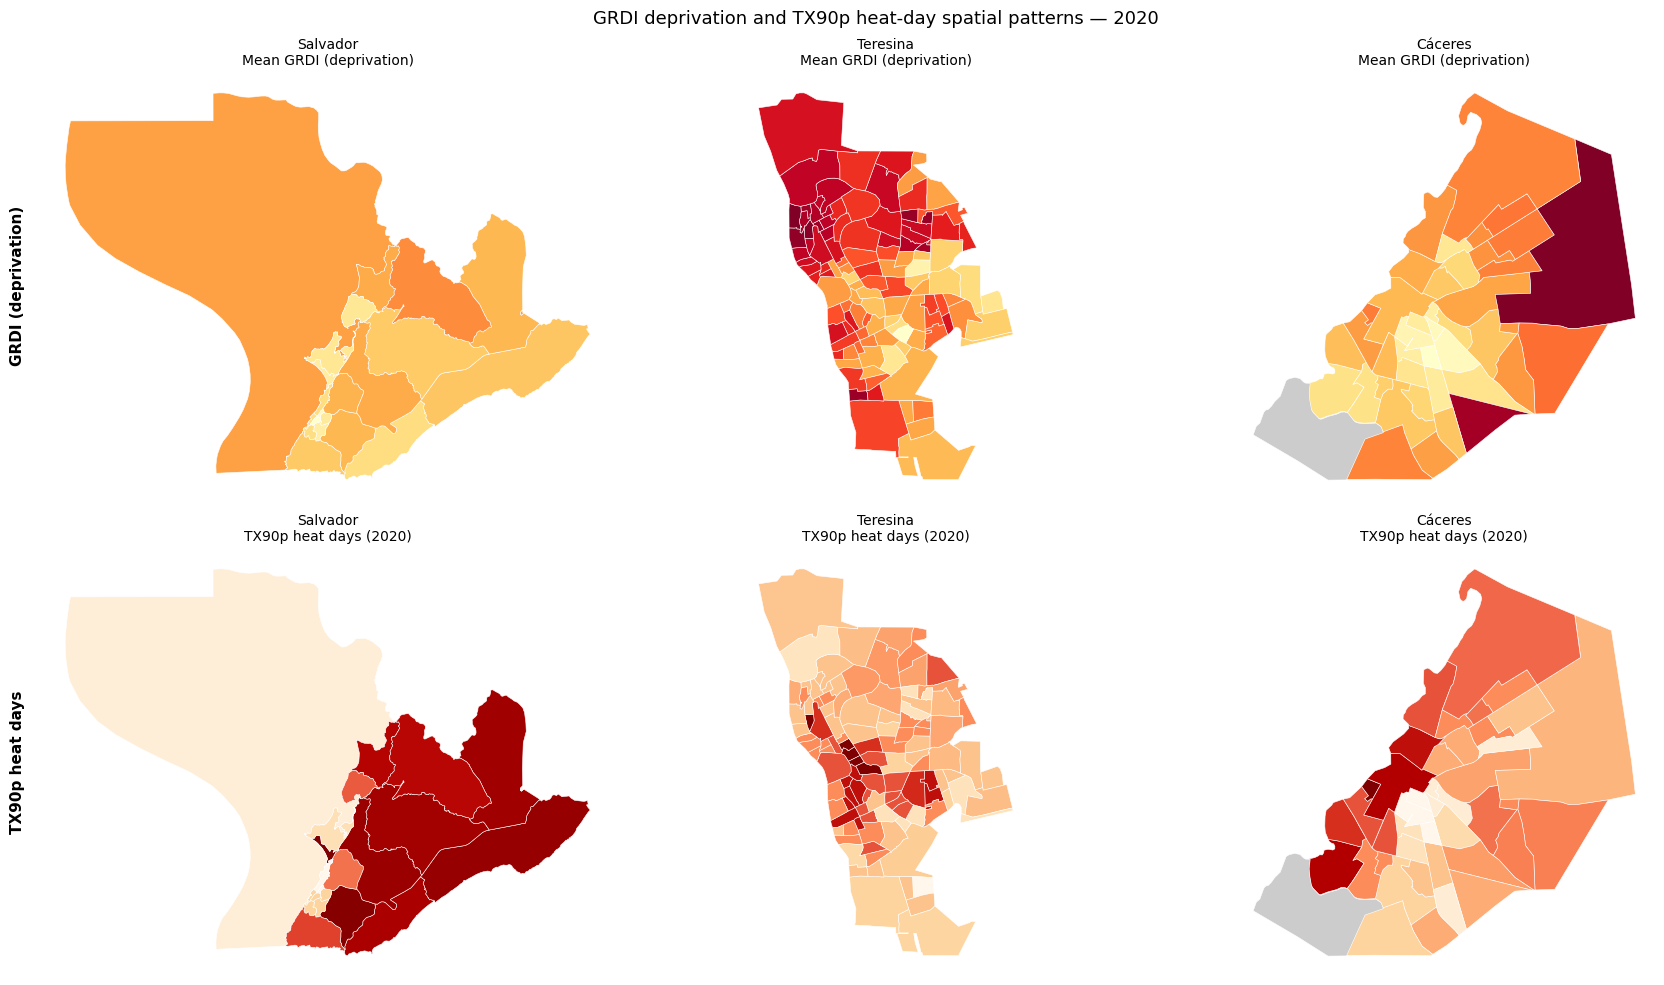

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'GRDI deprivation and TX90p heat-day spatial patterns — {DIAG_YEAR}',
    fontsize=13,
)

for col_idx, city in enumerate(CITY_KEYS):
    df  = city_df[city]
    gdf = districts[city].merge(df[['name', 'mean_grdi', 'tx90p_hd']], on='name', how='left')

    # Row 0: GRDI deprivation
    ax = axes[0, col_idx]
    gdf.plot(column='mean_grdi', ax=ax, cmap='YlOrRd',
             edgecolor='white', linewidth=0.4, legend=False,
             missing_kwds={'color': '#cccccc'})
    ax.set_title(f'{CITY_LABELS[city]}\nMean GRDI (deprivation)', fontsize=10)
    ax.set_axis_off()

    # Row 1: TX90p heat days
    ax = axes[1, col_idx]
    gdf.plot(column='tx90p_hd', ax=ax, cmap='OrRd',
             edgecolor='white', linewidth=0.4, legend=False,
             missing_kwds={'color': '#cccccc'})
    ax.set_title(f'{CITY_LABELS[city]}\nTX90p heat days ({DIAG_YEAR})', fontsize=10)
    ax.set_axis_off()

axes[0, 0].annotate('GRDI (deprivation)', xy=(-0.05, 0.5), xycoords='axes fraction',
                    rotation=90, va='center', fontsize=11, fontweight='bold')
axes[1, 0].annotate('TX90p heat days', xy=(-0.05, 0.5), xycoords='axes fraction',
                    rotation=90, va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 7 — CV comparison: GRDI vs heat days vs population

Coefficient of variation (std/mean) across neighbourhoods.  A higher CV means
greater spatial inequality in that variable.

CV (std/mean) across neighbourhoods — all three cities:


,Population,Abs heat days,TX90p heat days,Mean GRDI
City,,,,
Salvador,1.041,0.441,0.642,0.184
Teresina,0.878,0.012,0.190,0.144
Cáceres,0.511,0.007,0.024,0.113


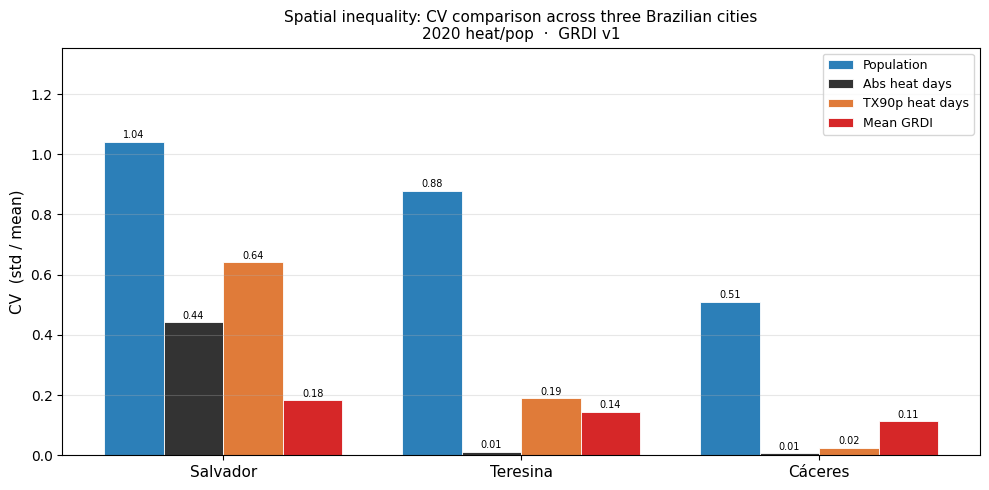

In [9]:
def cv(s):
    return s.std() / s.mean() if s.mean() != 0 else np.nan

cv_rows = []
for city in CITY_KEYS:
    df = city_df[city]
    cv_rows.append({
        'City':            CITY_LABELS[city],
        'Population':      cv(df['population']),
        'Abs heat days':   cv(df['abs_hd']),
        'TX90p heat days': cv(df['tx90p_hd']),
        'Mean GRDI':       cv(df['mean_grdi']),
    })

cv_df = pd.DataFrame(cv_rows)
print('CV (std/mean) across neighbourhoods — all three cities:')
display(
    cv_df.set_index('City').style
    .format('{:.3f}')
    .background_gradient(cmap='YlOrRd', axis=None)
    .set_caption('Coefficient of variation — higher = greater spatial inequality')
    .set_table_styles(table_styles)
)

cv_plot = cv_df.set_index('City')
x          = np.arange(len(CITY_KEYS))
w          = 0.2
cols_plot  = ['Population', 'Abs heat days', 'TX90p heat days', 'Mean GRDI']
colors     = ['#2c7fb8', '#333333', '#e07b39', '#d62728']

fig, ax = plt.subplots(figsize=(10, 5))
offsets = np.linspace(-(len(cols_plot)-1)/2 * w, (len(cols_plot)-1)/2 * w, len(cols_plot))
for col, color, offset in zip(cols_plot, colors, offsets):
    bars = ax.bar(x + offset, cv_plot[col], width=w, label=col,
                  color=color, edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, cv_plot[col]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([CITY_LABELS[c] for c in CITY_KEYS], fontsize=11)
ax.set_ylabel('CV  (std / mean)', fontsize=11)
ax.set_title(f'Spatial inequality: CV comparison across three Brazilian cities\n'
             f'{DIAG_YEAR} heat/pop  ·  GRDI v1', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, cv_plot.max().max() * 1.3)
plt.tight_layout()
plt.show()

## Step 8 — Spearman rank correlations: GRDI vs heat and population

**Expected direction:** a positive ρ between GRDI and heat days would mean more deprived
neighbourhoods also experience more heat — a compounding risk.  Negative ρ with population
would mean deprived areas are less populous (less total exposure despite high per-capita risk).

City,Cáceres,Salvador,Teresina
Comparison,,,
GRDI vs Abs heat days,-0.559,-0.114,-0.095
GRDI vs Population,-0.615,+0.490,+0.233
GRDI vs TX90p heat days,+0.464,+0.343,-0.161
GRDI vs TX90p person-days,-0.585,+0.532,+0.181
TX90p heat days vs Population,-0.359,+0.531,-0.133


City,Cáceres,Salvador,Teresina
Comparison,,,
GRDI vs Abs heat days,0.0001,0.6144,0.3180
GRDI vs Population,0.0000,0.0207,0.0133
GRDI vs TX90p heat days,0.0020,0.1187,0.0902
GRDI vs TX90p person-days,0.0000,0.0109,0.0556
TX90p heat days vs Population,0.0195,0.0111,0.1636


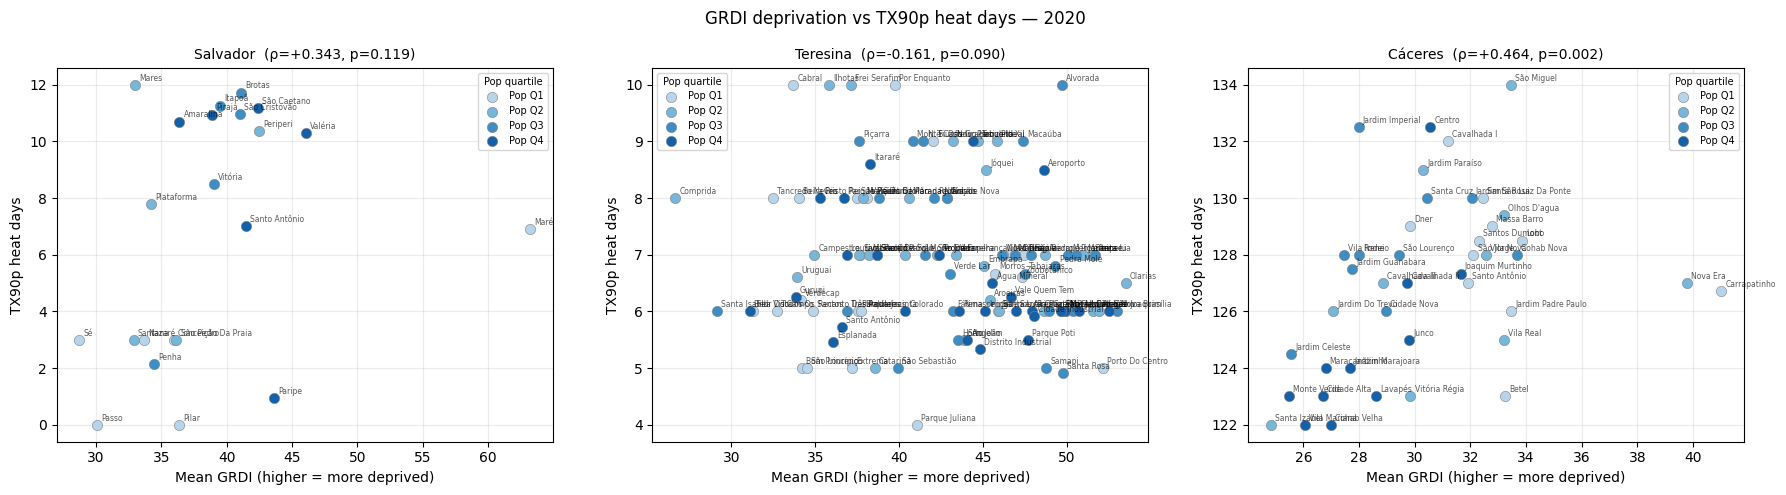

In [10]:
pairs = [
    ('mean_grdi', 'tx90p_hd',   'GRDI vs TX90p heat days'),
    ('mean_grdi', 'abs_hd',     'GRDI vs Abs heat days'),
    ('mean_grdi', 'population', 'GRDI vs Population'),
    ('mean_grdi', 'tx90p_pd',   'GRDI vs TX90p person-days'),
    ('tx90p_hd',  'population', 'TX90p heat days vs Population'),
]

rho_rows = []
for city in CITY_KEYS:
    df = city_df[city]
    for a, b, label in pairs:
        r, p = spearmanr(df[a], df[b])
        rho_rows.append({'City': CITY_LABELS[city], 'Comparison': label,
                         'ρ': r, 'p-value': p})

rho_table = pd.DataFrame(rho_rows)
display(
    rho_table.pivot(index='Comparison', columns='City', values='ρ')
    .style
    .format('{:+.3f}')
    .background_gradient(cmap='RdYlGn', vmin=-1, vmax=1, axis=None)
    .set_caption('Spearman ρ — GRDI deprivation vs heat/population by city\n'
                 '(positive = more deprived neighbourhoods have more heat/population)')
    .set_table_styles(table_styles)
)

# p-value table
display(
    rho_table.pivot(index='Comparison', columns='City', values='p-value')
    .style
    .format('{:.4f}')
    .background_gradient(cmap='YlOrRd_r', vmin=0, vmax=0.1, axis=None)
    .set_caption('p-values (darker = more significant)')
    .set_table_styles(table_styles)
)

# Scatter plots for GRDI vs TX90p heat days
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'GRDI deprivation vs TX90p heat days — {DIAG_YEAR}', fontsize=12)

for ax, city in zip(axes, CITY_KEYS):
    df = city_df[city]
    rho, p = spearmanr(df['mean_grdi'], df['tx90p_hd'])
    pop_q  = pd.qcut(df['population'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    cmap   = plt.cm.Blues
    for i, q in enumerate(['Q1', 'Q2', 'Q3', 'Q4']):
        mask = pop_q == q
        ax.scatter(df.loc[mask, 'mean_grdi'], df.loc[mask, 'tx90p_hd'],
                   s=55, color=cmap(0.3 + i * 0.17), edgecolors='grey',
                   linewidth=0.4, label=f'Pop {q}', zorder=3)
    for _, row in df.iterrows():
        ax.annotate(row['name'], (row['mean_grdi'], row['tx90p_hd']),
                    fontsize=5.5, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Mean GRDI (higher = more deprived)', fontsize=10)
    ax.set_ylabel('TX90p heat days', fontsize=10)
    ax.set_title(f'{CITY_LABELS[city]}  (ρ={rho:+.3f}, p={p:.3f})', fontsize=10)
    ax.legend(title='Pop quartile', fontsize=7, title_fontsize=7)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Step 9 — GRDI-weighted person-days

Higher GRDI = more deprived = **higher** vulnerability weight (inverted vs GDP notebook).

- Vulnerability = `normalised_grdi`  (not `1 − normalised_grdi`)
- Two normalisation methods: **A (min-max)** and **B (rank-percentile)**.

Neighbourhoods that already experience many heat days AND have high deprivation will
see their person-day rank rise further; affluent, heat-exposed neighbourhoods will fall.

In [11]:
def add_grdi_weights(df):
    """Adds GRDI vulnerability weights and weighted person-day columns in-place."""
    df = df.copy()
    n  = len(df)

    # Method A: min-max  (higher GRDI → higher vuln)
    g_min, g_max             = df['mean_grdi'].min(), df['mean_grdi'].max()
    df['grdi_norm_minmax']   = (df['mean_grdi'] - g_min) / (g_max - g_min)
    df['vuln_minmax']        = df['grdi_norm_minmax']
    df['weighted_pd_minmax'] = df['tx90p_pd'] * df['vuln_minmax']

    # Method B: rank percentile  (higher GRDI → higher vuln)
    df['grdi_rank_desc']    = df['mean_grdi'].rank(ascending=False, method='average')
    df['vuln_rank']         = (df['grdi_rank_desc'] - 1) / (n - 1)
    df['weighted_pd_rank']  = df['tx90p_pd'] * df['vuln_rank']

    # Ranks
    df['rank_unweighted']      = df['tx90p_pd'].rank(ascending=False, method='min').astype(int)
    df['rank_weighted_minmax'] = df['weighted_pd_minmax'].rank(ascending=False, method='min').astype(int)
    df['rank_weighted_rank']   = df['weighted_pd_rank'].rank(ascending=False, method='min').astype(int)
    df['rank_shift_minmax']    = df['rank_unweighted'] - df['rank_weighted_minmax']
    df['rank_shift_rank']      = df['rank_unweighted'] - df['rank_weighted_rank']
    return df


city_df_w = {city: add_grdi_weights(city_df[city]) for city in CITY_KEYS}

# Display Salvador weighted table
df_s = city_df_w['salvador']
display(
    df_s[['name', 'mean_grdi', 'tx90p_pd', 'vuln_minmax', 'vuln_rank',
          'weighted_pd_minmax', 'weighted_pd_rank',
          'rank_unweighted', 'rank_weighted_minmax', 'rank_weighted_rank']]
    .sort_values('rank_weighted_rank')
    .style
    .format({'mean_grdi': '{:.1f}', 'tx90p_pd': '{:,.0f}',
             'vuln_minmax': '{:.3f}', 'vuln_rank': '{:.3f}',
             'weighted_pd_minmax': '{:,.0f}', 'weighted_pd_rank': '{:,.0f}',
             'rank_unweighted': '{:.0f}', 'rank_weighted_minmax': '{:.0f}',
             'rank_weighted_rank': '{:.0f}'})
    .background_gradient(subset=['vuln_minmax', 'vuln_rank'], cmap='YlOrRd', vmin=0, vmax=1)
    .set_caption('Salvador — GRDI-weighted person-days  (Method A: min-max, Method B: rank)')
    .set_table_styles(table_styles)
)

,name,mean_grdi,tx90p_pd,vuln_minmax,vuln_rank,weighted_pd_minmax,weighted_pd_rank,rank_unweighted,rank_weighted_minmax,rank_weighted_rank
4,Pirajá,38.9,"4,006,178",0.294,0.476,"1,178,795","1,907,704",2,2,1
0,Amaralina,36.4,"2,845,064",0.221,0.524,"630,112","1,490,271",3,5,2
6,São Caetano,42.4,"4,303,580",0.395,0.190,"1,701,317","819,729",1,1,3
3,Itapoã,39.5,"1,982,070",0.312,0.381,"618,664","755,074",5,6,4
1,Brotas,41.1,"2,078,214",0.359,0.286,"745,260","593,775",4,4,5
21,Vitória,39.0,"1,167,467",0.299,0.429,"348,711","500,343",9,10,6
7,São Cristovão,41.0,"1,161,960",0.356,0.333,"413,100","387,320",10,9,7
5,Santo Antônio,41.5,"1,562,627",0.369,0.238,"576,408","372,054",7,7,8
16,Plataforma,34.2,"484,298",0.158,0.762,"76,475","368,989",12,12,9
13,Penha,34.5,"445,397",0.166,0.714,"73,989","318,141",13,13,10


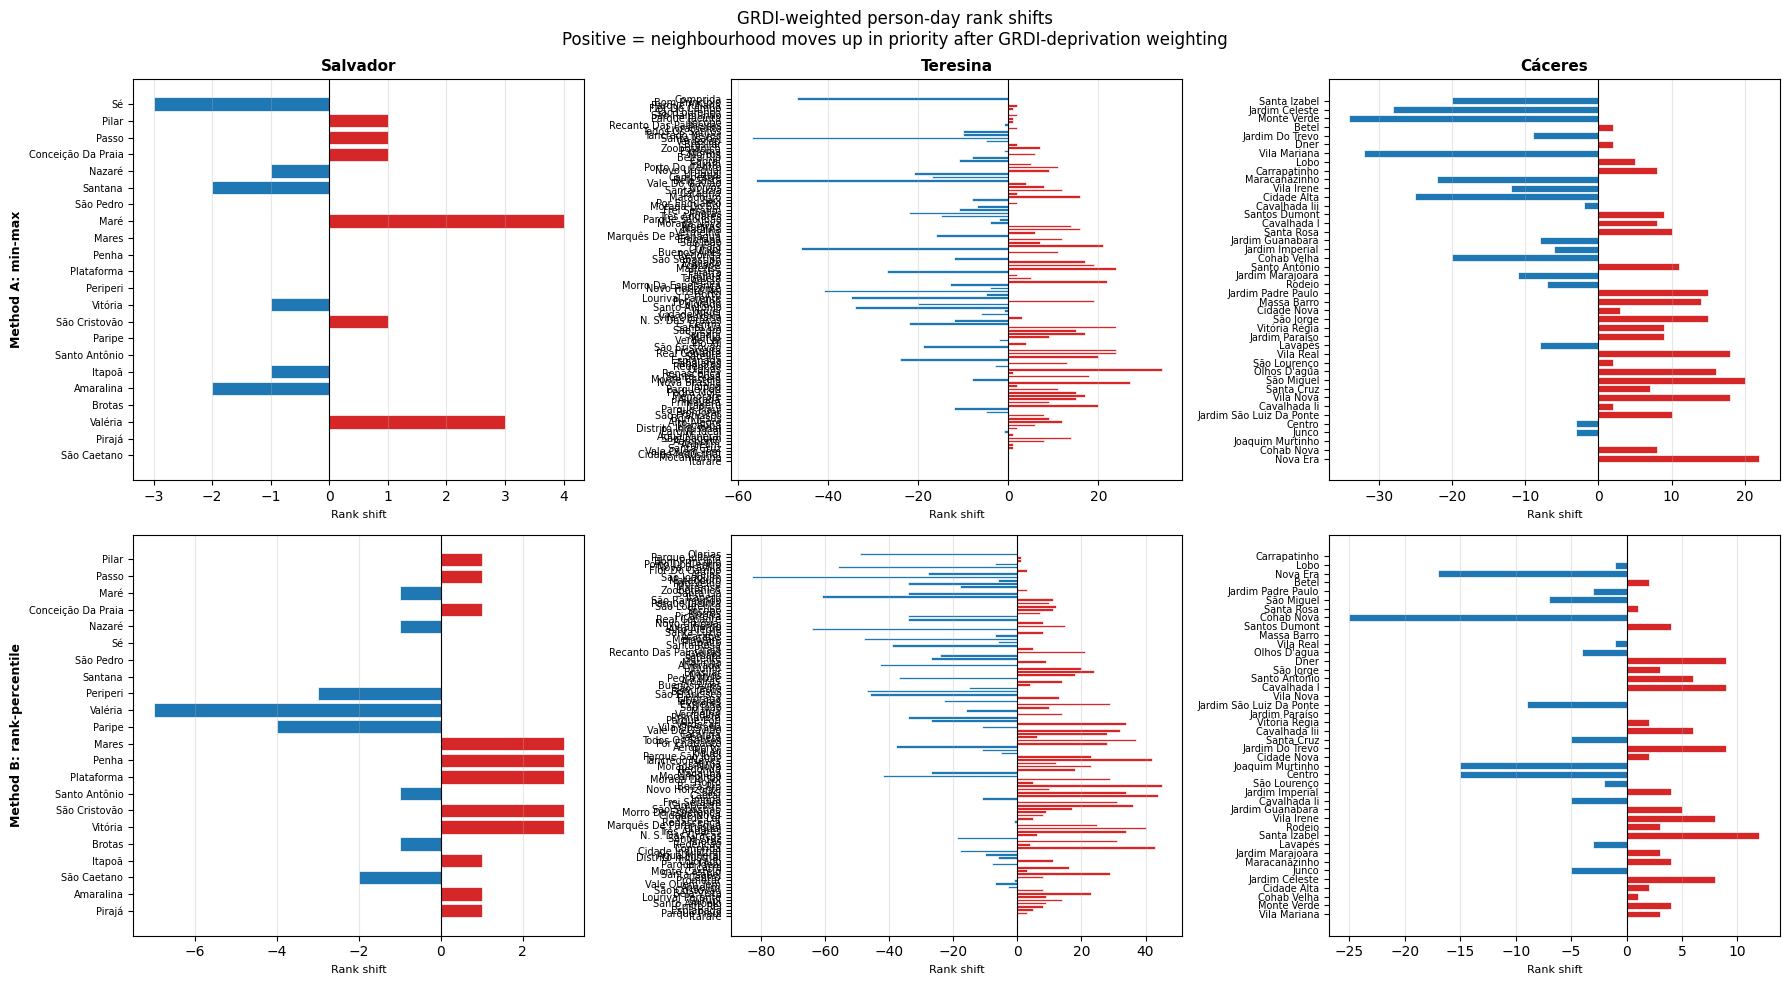

In [12]:
# Rank-shift bar charts for all three cities
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'GRDI-weighted person-day rank shifts\n'
    'Positive = neighbourhood moves up in priority after GRDI-deprivation weighting',
    fontsize=12,
)

for col_idx, city in enumerate(CITY_KEYS):
    df = city_df_w[city]
    for row_idx, (method, shift_col, title_suffix) in enumerate([
        ('rank_weighted_minmax', 'rank_shift_minmax', 'Method A: min-max'),
        ('rank_weighted_rank',   'rank_shift_rank',   'Method B: rank-percentile'),
    ]):
        ax      = axes[row_idx, col_idx]
        plot_df = df.sort_values(method).reset_index(drop=True)
        colors  = ['#d62728' if s > 0 else '#1f77b4' if s < 0 else '#aaaaaa'
                   for s in plot_df[shift_col]]
        ax.barh(plot_df['name'], plot_df[shift_col],
                color=colors, edgecolor='white', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Rank shift', fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(title_suffix, fontsize=9, fontweight='bold')
        if row_idx == 0:
            ax.set_title(CITY_LABELS[city], fontsize=11, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10 — Comparison with Census income ranks (Salvador only)

**Expected direction:** higher GRDI (more deprived) should correlate with **lower** census income.
A negative Spearman ρ between GRDI and income would confirm that the poverty index
captures the same gradient as household income data.

A strong negative ρ validates GRDI as a proxy for income deprivation in Salvador;
weak/positive ρ would suggest the multidimensional index diverges from income alone
(e.g. areas with low income but high nighttime light intensity, or vice versa).

This cell only runs if the Salvador income GeoJSON from notebook 10 is present.

Salvador GRDI vs income correlation: ρ = -0.396  (p = 0.0682)
  → Weak negative: GRDI and income partially diverge in this city.


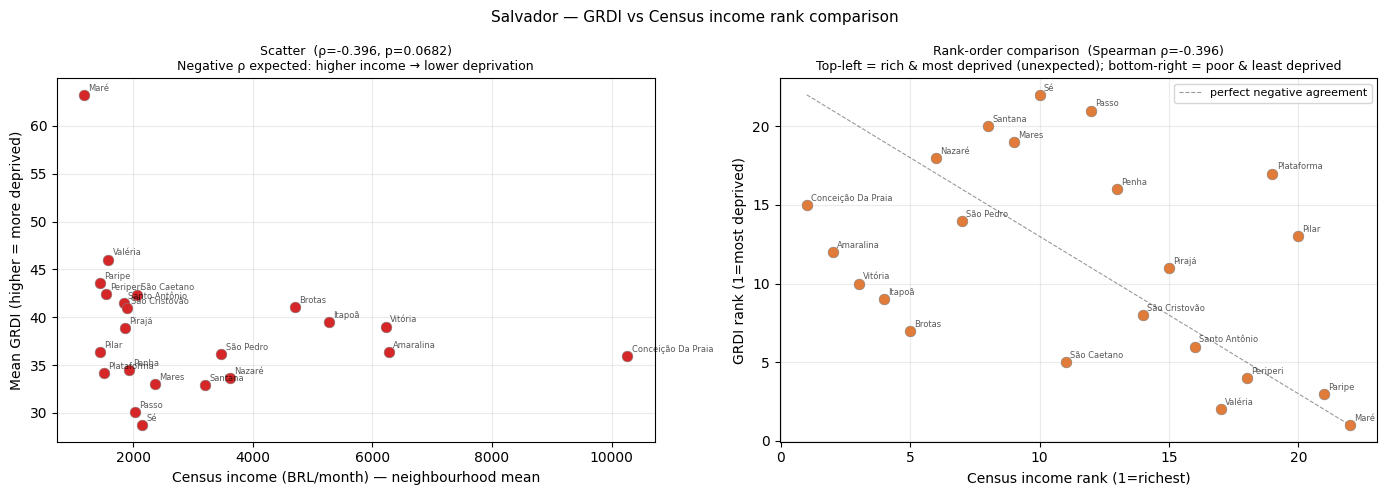

,name,mean_income,mean_grdi,rank_income,rank_grdi,rank_diff
16,Plataforma,1511,34.2,19,17,13
1,Brotas,4701,41.1,5,7,11
21,Vitória,6220,39.0,3,10,10
3,Itapoã,5277,39.5,4,9,10
15,Pilar,1452,36.3,20,13,10
12,Passo,2026,30.1,12,21,10
19,Sé,2147,28.7,10,22,9
0,Amaralina,6270,36.4,2,12,9
6,São Caetano,2059,42.4,11,5,7
2,Conceição Da Praia,10261,36.0,1,15,7


In [13]:
INCOME_FILE  = 'data/renda_responsavel_2927408_georedus_censo_2022.geojson'
PROJ_CRS_SAL = CITY_PROJ_CRS['salvador']

if not Path(INCOME_FILE).exists():
    print(f'Income GeoJSON not found: {INCOME_FILE}')
    print('Run notebook 10 first to generate the income data, then re-run this cell.')
    print('\nSkipping GRDI vs income comparison.')
else:
    income_raw  = gpd.read_file(INCOME_FILE)
    income_gdf  = income_raw.dropna(subset=['renda_responsavel']).reset_index(drop=True)
    income_gdf  = income_gdf.to_crs(districts['salvador'].crs)

    income_proj = income_gdf.to_crs(PROJ_CRS_SAL)
    dist_proj   = districts['salvador'].to_crs(PROJ_CRS_SAL)

    income_pts  = income_gdf[['id', 'renda_responsavel']].copy()
    income_pts['geometry'] = income_proj.geometry.centroid
    income_pts  = gpd.GeoDataFrame(income_pts, crs=PROJ_CRS_SAL)

    joined = gpd.sjoin(income_pts, dist_proj[['name', 'geometry']],
                       how='left', predicate='within')
    unmatched = joined['name'].isna()
    if unmatched.sum() > 0:
        nearest = gpd.sjoin_nearest(
            income_pts.loc[unmatched],
            dist_proj[['name', 'geometry']], how='left'
        )[['name']]
        joined.loc[unmatched, 'name'] = nearest['name'].values

    income_by_nbhd = (
        joined.groupby('name')['renda_responsavel']
        .mean().reset_index().rename(columns={'renda_responsavel': 'mean_income'})
    )

    compare = city_df_w['salvador'][['name', 'mean_grdi']].merge(
        income_by_nbhd, on='name', how='inner'
    )
    compare['rank_grdi']   = compare['mean_grdi'].rank(ascending=False, method='min')
    compare['rank_income'] = compare['mean_income'].rank(ascending=False, method='min')
    rho_gi, p_gi = spearmanr(compare['mean_grdi'], compare['mean_income'])

    print(f'Salvador GRDI vs income correlation: ρ = {rho_gi:+.3f}  (p = {p_gi:.4f})')
    if rho_gi <= -0.7:
        print('  → Strong negative: GRDI deprivation aligns well with low income (as expected).')
    elif rho_gi <= -0.4:
        print('  → Moderate negative: GRDI partially captures income inequality.')
    elif rho_gi <= 0.0:
        print('  → Weak negative: GRDI and income partially diverge in this city.')
    else:
        print('  → Positive: unexpected — GRDI and income move in the same direction, '
              'suggesting the index may be dominated by non-income components here.')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Salvador — GRDI vs Census income rank comparison',
                 fontsize=11)

    ax = axes[0]
    ax.scatter(compare['mean_income'], compare['mean_grdi'], s=60,
               color='#d62728', edgecolors='grey', linewidth=0.4, zorder=3)
    for _, row in compare.iterrows():
        ax.annotate(row['name'], (row['mean_income'], row['mean_grdi']),
                    fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Census income (BRL/month) — neighbourhood mean', fontsize=10)
    ax.set_ylabel('Mean GRDI (higher = more deprived)', fontsize=10)
    ax.set_title(f'Scatter  (ρ={rho_gi:+.3f}, p={p_gi:.4f})\n'
                 'Negative ρ expected: higher income → lower deprivation', fontsize=9)
    ax.grid(True, alpha=0.25)

    ax = axes[1]
    ax.scatter(compare['rank_income'], compare['rank_grdi'], s=60,
               color='#e07b39', edgecolors='grey', linewidth=0.4, zorder=3)
    for _, row in compare.iterrows():
        ax.annotate(row['name'], (row['rank_income'], row['rank_grdi']),
                    fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.plot([1, len(compare)], [len(compare), 1], 'k--', lw=0.8, alpha=0.4,
            label='perfect negative agreement')
    ax.set_xlabel('Census income rank (1=richest)', fontsize=10)
    ax.set_ylabel('GRDI rank (1=most deprived)', fontsize=10)
    ax.set_title(f'Rank-order comparison  (Spearman ρ={rho_gi:+.3f})\n'
                 'Top-left = rich & most deprived (unexpected); bottom-right = poor & least deprived',
                 fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(
        compare[['name', 'mean_income', 'mean_grdi', 'rank_income', 'rank_grdi']]
        .assign(rank_diff=lambda d: (d['rank_grdi'] - (len(compare) + 1 - d['rank_income'])).abs())
        .sort_values('rank_diff', ascending=False)
        .style
        .format({'mean_income': '{:.0f}', 'mean_grdi': '{:.1f}',
                 'rank_income': '{:.0f}', 'rank_grdi': '{:.0f}', 'rank_diff': '{:.0f}'})
        .background_gradient(subset=['rank_diff'], cmap='YlOrRd')
        .set_caption('Salvador: largest rank disagreements between GRDI and census income')
        .set_table_styles(table_styles)
    )

## Step 11 — GRDI vs GDP rank comparison (Salvador)

Directly compares the rank ordering from the GRDI poverty index with the GDP raster
from notebook 10b.  If both datasets capture the same underlying inequality,
we expect a strong negative Spearman ρ (high GDP = low deprivation = low GRDI).

Divergences highlight neighbourhoods where the two datasets disagree — these are
analytically interesting: e.g. high economic output but high deprivation (dense
informal settlements within productive urban areas).

Salvador GRDI vs GDP correlation: ρ = -0.443  (p = 0.0388)
  → Moderate negative: GRDI and GDP partially agree on spatial inequality.


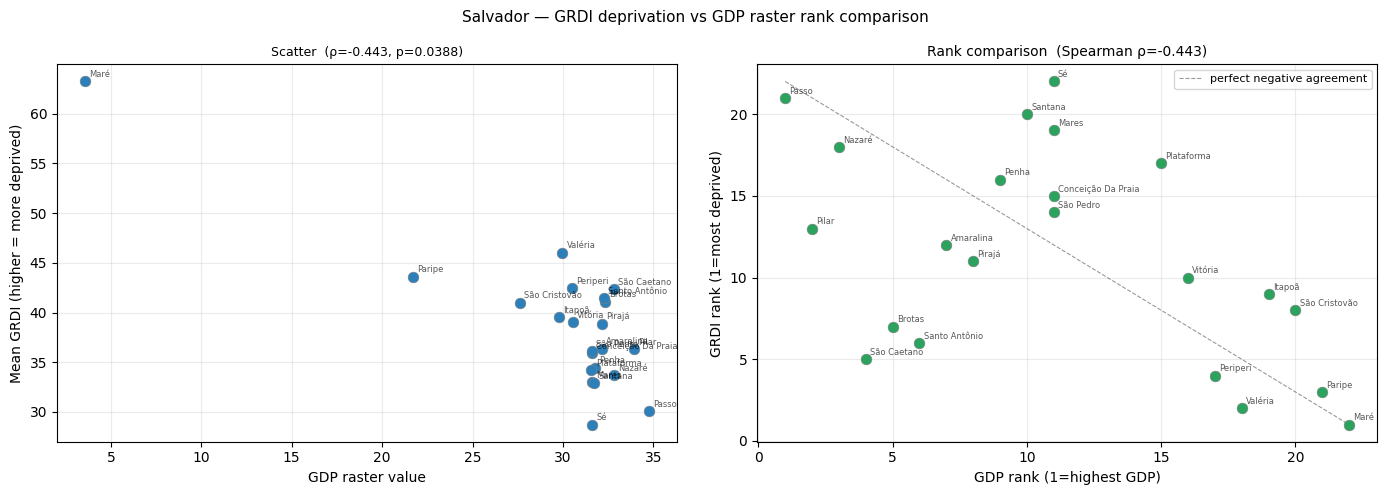

,name,mean_gdp,mean_grdi,rank_gdp,rank_grdi,rank_diff
6,São Caetano,32.82,42.4,4,5,14
5,Santo Antônio,32.28,41.5,6,6,11
1,Brotas,32.33,41.1,5,7,11
19,Sé,31.61,28.7,11,22,10
16,Plataforma,31.58,34.2,15,17,9
15,Pilar,33.95,36.3,2,13,8
9,Mares,31.61,33.0,11,19,7
17,Santana,31.73,32.9,10,20,7
3,Itapoã,29.80,39.5,19,9,5
7,São Cristovão,27.63,41.0,20,8,5


In [14]:
GDP_TIF_SAL = Path(DATA_DIR) / 'gdp_2019_salvador.tif'

if not GDP_TIF_SAL.exists():
    print(f'GDP cache not found: {GDP_TIF_SAL}')
    print('Run notebook 10b first to generate the cached GDP file, then re-run this cell.')
    print('\nSkipping GRDI vs GDP comparison.')
else:
    from utils.heat import load_neighbourhood_boundaries

    # Re-use the gdp_zonal_stats logic inline (avoid importing from 10b)
    def gdp_zonal_stats_quick(gdf_4326, gdp_tif_path, raster_crs='ESRI:54009'):
        gdf_proj = gdf_4326.to_crs(raster_crs)
        rows = []
        with rasterio.open(gdp_tif_path) as src:
            nodata = src.nodata
            for _, row in gdf_proj.iterrows():
                try:
                    out_arr, _ = rio_mask(
                        src, [mapping(row.geometry)], crop=True,
                        nodata=nodata, all_touched=True,
                    )
                    vals = out_arr[0].astype(float)
                    if nodata is not None:
                        vals[np.isclose(vals, nodata)] = np.nan
                    valid    = vals[np.isfinite(vals) & (vals > 0)]
                    mean_val = float(valid.mean()) if len(valid) > 0 else np.nan
                except Exception:
                    mean_val = np.nan
                rows.append({'name': row['name'], 'mean_gdp': mean_val})
        return pd.DataFrame(rows)

    gdp_sal = gdp_zonal_stats_quick(districts['salvador'], str(GDP_TIF_SAL))

    compare_gg = city_df_w['salvador'][['name', 'mean_grdi']].merge(
        gdp_sal, on='name', how='inner'
    ).dropna()

    compare_gg['rank_grdi'] = compare_gg['mean_grdi'].rank(ascending=False, method='min')
    compare_gg['rank_gdp']  = compare_gg['mean_gdp'].rank(ascending=False, method='min')
    rho_gg, p_gg = spearmanr(compare_gg['mean_grdi'], compare_gg['mean_gdp'])

    print(f'Salvador GRDI vs GDP correlation: ρ = {rho_gg:+.3f}  (p = {p_gg:.4f})')
    if rho_gg <= -0.7:
        print('  → Strong negative agreement: high-GDP neighbourhoods are low-GRDI (as expected).')
    elif rho_gg <= -0.4:
        print('  → Moderate negative: GRDI and GDP partially agree on spatial inequality.')
    else:
        print('  → Weak/positive: GRDI and GDP capture different aspects of neighbourhood wealth.')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Salvador — GRDI deprivation vs GDP raster rank comparison', fontsize=11)

    ax = axes[0]
    ax.scatter(compare_gg['mean_gdp'], compare_gg['mean_grdi'], s=60,
               color='#2c7fb8', edgecolors='grey', linewidth=0.4, zorder=3)
    for _, row in compare_gg.iterrows():
        ax.annotate(row['name'], (row['mean_gdp'], row['mean_grdi']),
                    fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('GDP raster value', fontsize=10)
    ax.set_ylabel('Mean GRDI (higher = more deprived)', fontsize=10)
    ax.set_title(f'Scatter  (ρ={rho_gg:+.3f}, p={p_gg:.4f})', fontsize=9)
    ax.grid(True, alpha=0.25)

    ax = axes[1]
    ax.scatter(compare_gg['rank_gdp'], compare_gg['rank_grdi'], s=60,
               color='#2ca25f', edgecolors='grey', linewidth=0.4, zorder=3)
    for _, row in compare_gg.iterrows():
        ax.annotate(row['name'], (row['rank_gdp'], row['rank_grdi']),
                    fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
    ax.plot([1, len(compare_gg)], [len(compare_gg), 1], 'k--', lw=0.8, alpha=0.4,
            label='perfect negative agreement')
    ax.set_xlabel('GDP rank (1=highest GDP)', fontsize=10)
    ax.set_ylabel('GRDI rank (1=most deprived)', fontsize=10)
    ax.set_title(f'Rank comparison  (Spearman ρ={rho_gg:+.3f})', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(
        compare_gg[['name', 'mean_gdp', 'mean_grdi', 'rank_gdp', 'rank_grdi']]
        .assign(rank_diff=lambda d: (d['rank_grdi'] - (len(compare_gg) + 1 - d['rank_gdp'])).abs())
        .sort_values('rank_diff', ascending=False)
        .style
        .format({'mean_gdp': '{:.2f}', 'mean_grdi': '{:.1f}',
                 'rank_gdp': '{:.0f}', 'rank_grdi': '{:.0f}', 'rank_diff': '{:.0f}'})
        .background_gradient(subset=['rank_diff'], cmap='YlOrRd')
        .set_caption('Salvador: largest rank disagreements between GRDI and GDP')
        .set_table_styles(table_styles)
    )

## Summary

### What this notebook establishes

1. **Efficient extraction** — city GRDI windows are read from the global raster using
   rasterio windowed reads.  No reprojection needed (raster is already EPSG:4326).
   Extracted city files are cached in `data/grdi_{city}.tif`.

2. **GRDI spatial patterns** — choropleth maps show intra-urban deprivation variation
   across neighbourhood boundaries for Salvador (22), Teresina (112), and Cáceres (43).

3. **CV comparison** — relative spatial inequality in GRDI is compared against
   population and heat-day variation within each city.

4. **GRDI–heat correlation** — Spearman ρ tests whether more deprived neighbourhoods
   are systematically exposed to more heat (a compounding risk).  Positive ρ supports
   GRDI as a vulnerability amplifier for the heat risk index.

5. **GRDI-weighted person-days** — two normalisation methods (min-max, rank-percentile)
   produce vulnerability-adjusted priority indices where deprivation **amplifies** exposure.

6. **GRDI vs income (Salvador, conditional)** — Spearman ρ between GRDI and census income.
   Strong negative ρ validates GRDI as a proxy for income deprivation.

7. **GRDI vs GDP (Salvador, conditional)** — direct comparison with the Kummu GDP raster
   from notebook 10b.  Divergences identify neighbourhoods where the two proxies disagree.

### Key differences from notebook 10b (GDP)

| Feature | GDP (10b) | GRDI (10c) |
|---|---|---|
| CRS | ESRI:54009 (Mollweide) | EPSG:4326 (WGS84) |
| Units | USD PPP/km² | 0–100 relative index |
| Direction | Higher = wealthier = lower vulnerability | Higher = more deprived = higher vulnerability |
| Vulnerability weight | `1 − normalised_gdp` | `normalised_grdi` |
| Dimensions | Economic output only | CDR + IMR + HDI + built-up + nighttime lights |
| Cross-city comparability | Limited (mixes area + output) | Yes (relative index, 0–100) |

### Known limitations

- **Resolution mismatch:** GRDI is ~1 km (~0.01°).  Small neighbourhoods may be represented
  by very few pixels.  `all_touched=True` ensures coverage but a neighbourhood's GRDI value
  may reflect an area larger than its actual boundary.

- **Temporal coverage:** GRDI v1 spans 2010–2020 (composite).  Heat and population data
  use 2020.  For rapidly urbanising areas this gap may matter.

- **Relative vs absolute:** GRDI measures deprivation *relative* to the global distribution,
  not absolute poverty.  A neighbourhood in Salvador with GRDI=40 may still be wealthier
  in absolute terms than one in a low-income country with GRDI=30.

- **Citation:** Center for International Earth Science Information Network (CIESIN),
  Columbia University. 2022. Global Gridded Relative Deprivation Index (GRDI), Version 1.
  NASA SEDAC. https://doi.org/10.7927/3xxe-ap97